# Welltory COVID-19 and Wearables Data Exploration

**Author:** Snehal Jindal  
**Course:** AIPI 510 - Data Sourcing and Analytics  
**Activity:** Week 4 Data Exploration Challenge

## Objective

This notebook explores the Welltory COVID-19 and Wearables Open Data Research dataset. The analysis covers data structure, feature meaning, descriptive statistics, missing values, duplicates, outliers, transformations, visual relationships, and new feature creation. Each cleaning choice is explained so that the analysis is reproducible and the raw data remains unchanged.

## Data context, sampling, and provenance

Welltory conducted the research in 2020 to study patterns related to COVID-19 progression and recovery. Participants with a positive COVID-19 status used the Welltory app to record symptoms and heart rate variability (HRV). The repository also contains measurements from connected wearables, survey responses, sleep records, blood pressure, heart rate, and weather.

The data is an observational, self-selected sample of Welltory users. It is not a random sample of the general population. Participants contributed different numbers and types of measurements, so the tables have unequal coverage and repeated observations. Results should therefore be interpreted as exploratory associations rather than causal or population-level conclusions.

Welltory states that the records are anonymized and do not contain names or email addresses. The downloaded CSV files are treated as immutable raw inputs in this notebook.

**Sources**

- [Welltory COVID-19 and Wearables Open Data Research](https://github.com/Welltory/hrv-covid19)
- [Technical description of the CSV fields](https://github.com/Welltory/hrv-covid19/blob/master/datatypes.md)
- [Dataset license](https://github.com/Welltory/hrv-covid19/blob/master/LICENSE)


## 1. Environment and analysis plan

The course repository lists NumPy 1.26.4, pandas 2.1.3, matplotlib 3.8.0, and seaborn 0.13.2 in `requirements.txt`. The code below uses only standard features from those packages and Python 3.11.

The workflow is:

1. Load all nine CSV files without changing them.
2. Profile every table for dimensions, data types, missingness, and exact duplicates.
3. Focus detailed analysis on `hrv_measurements` and `participants` because HRV is central to the research and the participant table supplies demographic context.
4. Validate identifiers, dates, units, and internal relationships.
5. Apply documented strategies for missing values, duplicates, and outliers.
6. Engineer useful features and examine distributions and relationships.
7. Summarize data quality, limitations, and findings.


In [1]:
# Import Path so file locations work across operating systems.
from pathlib import Path

# Import NumPy for numerical calculations and missing-value handling.
import numpy as np

# Import pandas for reading CSV files and working with tabular data.
import pandas as pd

# Import matplotlib's plotting interface for figure creation.
import matplotlib.pyplot as plt

# Import seaborn for readable statistical visualizations.
import seaborn as sns

# Display every column when a DataFrame is shown in the notebook.
pd.set_option("display.max_columns", None)

# Limit displayed rows so large tables remain readable.
pd.set_option("display.max_rows", 100)

# Use a consistent visual style for every chart.
sns.set_theme(style="whitegrid", context="notebook")

# Use a consistent figure size unless a later chart needs a different layout.
plt.rcParams["figure.figsize"] = (10, 5)

print("Analysis libraries imported successfully.")


Analysis libraries imported successfully.


## 2. Load and inventory the raw data

The notebook is stored in `data-exploration/`, while the raw CSV files are stored in `data/welltory/`. The relative path `../data/welltory` moves up one folder from the notebook and then enters the data folder. Each CSV is loaded into a dictionary under its filename. This preserves the nine source tables instead of combining tables that have different units and sampling frequencies.


In [2]:
# Define the location of the raw Welltory CSV files relative to this notebook.
DATA_DIR = Path("../data/welltory")

# Stop immediately with a clear message if the expected data folder is missing.
if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Expected the raw CSV files in ../data/welltory. "
        "Download the Welltory data and place the CSV files in that folder."
    )

# Find every CSV file and sort the paths to keep the load order reproducible.
csv_files = sorted(DATA_DIR.glob("*.csv"))

# Confirm that the expected nine raw tables are available.
if len(csv_files) != 9:
    raise ValueError(f"Expected 9 CSV files, but found {len(csv_files)}.")

# Read each CSV into its own DataFrame; the filename without '.csv' becomes the key.
datasets = {
    file_path.stem: pd.read_csv(file_path)
    for file_path in csv_files
}

# Print the loaded names so a reviewer can verify the data inventory.
print("Loaded datasets:")
for dataset_name in datasets:
    print(f"- {dataset_name}")


Loaded datasets:
- blood_pressure
- heart_rate
- hrv_measurements
- participants
- scales_description
- sleep
- surveys
- wearables
- weather


## 3. Dataset-wide profiling

The first profile covers every source table. Row and column counts describe structure. Missing-cell percentages measure overall completeness. Exact duplicate counts provide an initial duplication check, although key-level duplication is tested separately later.


In [3]:
# Create one summary record for every raw dataset.
profile_records = []

# Loop through each dataset so the same checks are applied consistently.
for dataset_name, dataframe in datasets.items():
    # Count all cells in the table for the missingness denominator.
    total_cells = dataframe.size

    # Count cells represented as missing values.
    missing_cells = int(dataframe.isna().sum().sum())

    # Add the table's structural and quality measures to the summary list.
    profile_records.append(
        {
            "dataset": dataset_name,
            "rows": len(dataframe),
            "columns": dataframe.shape[1],
            "missing_cells": missing_cells,
            "missing_percent": round(missing_cells / total_cells * 100, 2),
            "exact_duplicate_rows": int(dataframe.duplicated().sum()),
        }
    )

# Convert the records to a DataFrame and sort by dataset name.
dataset_profile = (
    pd.DataFrame(profile_records)
    .sort_values("dataset")
    .reset_index(drop=True)
)

# Display the complete dataset-level profile.
display(dataset_profile)


,dataset,rows,columns,missing_cells,missing_percent,exact_duplicate_rows
0,blood_pressure,721,8,1704,29.54,0
1,heart_rate,523783,4,0,0.00,0
2,hrv_measurements,3245,22,2823,3.95,0
3,participants,185,8,58,3.92,0
4,scales_description,148,4,0,0.00,0
5,sleep,425,12,2873,56.33,0
6,surveys,2259,5,0,0.00,0
7,wearables,3098,18,26887,48.22,0
8,weather,1717,7,0,0.00,0


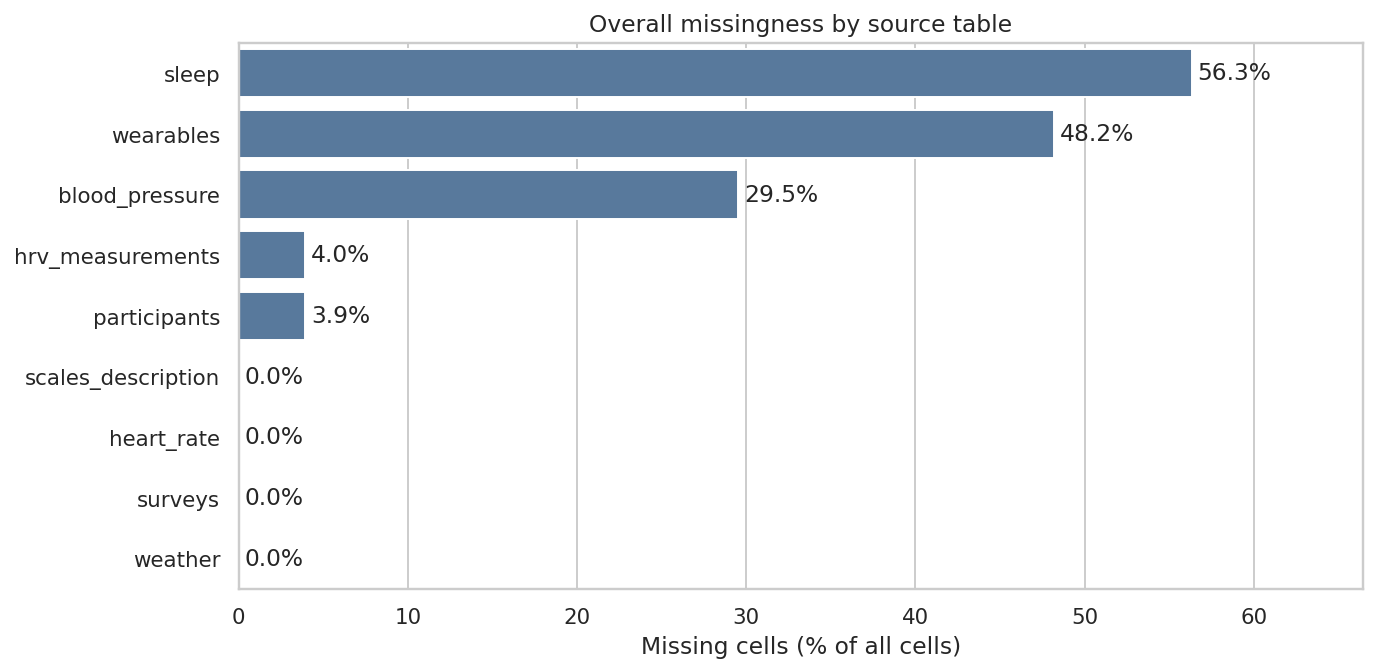

In [4]:
# Sort from least to most complete so the missingness comparison is easy to read.
missingness_plot_data = dataset_profile.sort_values("missing_percent", ascending=False)

# Create the chart canvas and axis.
fig, ax = plt.subplots(figsize=(10, 5))

# Draw one horizontal bar for each source table.
sns.barplot(
    data=missingness_plot_data,
    x="missing_percent",
    y="dataset",
    color="#4C78A8",
    ax=ax,
)

# State exactly what the horizontal scale measures.
ax.set_xlabel("Missing cells (% of all cells)")

# The dataset names already identify the vertical axis.
ax.set_ylabel("")

# Use a direct title that describes the comparison.
ax.set_title("Overall missingness by source table")

# Add the exact percentage beside every bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

# Add room for the labels to the right of the longest bar.
ax.set_xlim(0, max(missingness_plot_data["missing_percent"].max() * 1.18, 5))

# Prevent labels from being clipped.
plt.tight_layout()

# Render the chart in the notebook.
plt.show()


### Dataset-wide profile interpretation

The nine tables vary substantially in size. `heart_rate` is the largest with 523,783 rows, while `scales_description` is the smallest with 148 rows. This reflects different collection frequencies: heart rate can be recorded repeatedly, while the scale-description table is reference data.

Missingness is concentrated in `sleep` (56.33%), `wearables` (48.22%), and `blood_pressure` (29.54%). In contrast, `heart_rate`, `scales_description`, `surveys`, and `weather` have no missing cells. No source table contains an exact duplicate row.

I do not remove all incomplete rows. The missingness pattern likely reflects differences in devices, participant behavior, and optional inputs. Complete-case deletion across the full dataset would discard substantial information and could bias the sample toward participants who recorded more data.


## 4. Feature structure and meaning

The code below creates a compact data dictionary for all 88 fields. It records the detected type, non-missing count, number of distinct values, and representative values. The official `datatypes.md` file provides the field definitions and units.

Key HRV features used later include:

| Feature | Meaning | Unit |
|---|---|---|
| `bpm` | Heart rate during the measurement | beats per minute |
| `meanrr` | Mean time between consecutive heartbeats | milliseconds |
| `sdnn` | Standard deviation of normal heartbeat intervals | milliseconds |
| `rmssd` | Root mean square of successive interval differences | milliseconds |
| `pnn50` | Welltory's percentage-based RR-interval variability measure | percent |
| `lf`, `hf`, `vlf` | Low-, high-, and very-low-frequency spectral power | milliseconds squared |
| `lfhf` | Ratio of low- to high-frequency power | ratio |
| `total_power` | Sum of LF, HF, and VLF power | milliseconds squared |
| `how_feel`, `how_mood`, `how_sleep` | Post-measurement self-reported scores | ordinal scores |
| `rr_data` | Comma-separated RR intervals | milliseconds |

Participant `height` is documented in centimeters, `weight` in kilograms, and `symptoms_onset` in MM/DD/YYYY format.


In [5]:
# Store one profile row for each feature across all datasets.
schema_records = []

# Visit every table and every column within that table.
for dataset_name, dataframe in datasets.items():
    for column_name in dataframe.columns:
        # Remove missing values before collecting representative examples.
        non_missing_values = dataframe[column_name].dropna()

        # Convert at most three distinct examples to text for a compact display.
        example_values = ", ".join(
            non_missing_values.astype(str).unique()[:3]
        )

        # Save structural information about the current feature.
        schema_records.append(
            {
                "dataset": dataset_name,
                "column": column_name,
                "dtype": str(dataframe[column_name].dtype),
                "non_null": int(non_missing_values.shape[0]),
                "unique_values": int(non_missing_values.nunique()),
                "example_values": example_values,
            }
        )

# Assemble the feature-level profile.
schema = pd.DataFrame(schema_records)

# Display the features used in the detailed analysis.
focus_schema = schema[
    schema["dataset"].isin(["hrv_measurements", "participants"])
].reset_index(drop=True)

display(focus_schema)


,dataset,column,dtype,non_null,unique_values,example_values
0,hrv_measurements,user_code,object,3245,185,"007b8190cf, 013f6d3e5b, 01bad5a519"
1,hrv_measurements,rr_code,object,3245,3245,"10489a6aea, 9610d4d4dc, f3de056155"
2,hrv_measurements,measurement_datetime,object,3245,3241,"2020-04-21 21:23:08, 2020-04-26 11:19:25, 2020..."
3,hrv_measurements,time_of_day,object,3245,4,"morning, night, day"
4,hrv_measurements,bpm,int64,3245,71,"75, 70, 83"
5,hrv_measurements,meanrr,float64,3245,3134,"795.9, 858.0, 724.1"
6,hrv_measurements,mxdmn,float64,3245,66,"0.12, 0.11, 0.17"
7,hrv_measurements,sdnn,float64,3245,3180,"45.802, 32.889, 54.811"
8,hrv_measurements,rmssd,float64,3245,3174,"54.174, 33.022, 65.987"
9,hrv_measurements,pnn50,float64,3245,146,"15.15, 16.16, 17.17"


## 5. Detailed analytical focus

The detailed analysis uses `hrv_measurements` and `participants`. HRV is central to the research objective, and participant attributes provide context. The anonymized `user_code` connects the tables. I keep the other seven tables in the dataset-wide profile but do not combine all of them because they have different time grains, device coverage, and meanings. Combining them without a specific research question would create unnecessary missingness and risk invalid comparisons.


In [6]:
# Create working copies so the raw DataFrames in the datasets dictionary remain unchanged.
hrv_raw = datasets["hrv_measurements"].copy()
participants_raw = datasets["participants"].copy()

# Display representative rows before any cleaning or type conversion.
print("HRV measurement sample:")
display(hrv_raw.head())

# Display participant records separately because this table has one row per participant.
print("Participant sample:")
display(participants_raw.head())

# Select the primary numerical HRV measures used in later summaries and plots.
hrv_numeric_columns = [
    "bpm",
    "meanrr",
    "mxdmn",
    "sdnn",
    "rmssd",
    "pnn50",
    "mode",
    "amo",
    "lf",
    "hf",
    "vlf",
    "lfhf",
    "total_power",
]

# Calculate robust and conventional descriptive statistics for the HRV measures.
hrv_descriptive_statistics = hrv_raw[hrv_numeric_columns].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T

# Show the statistics with variables as rows for easier comparison.
display(hrv_descriptive_statistics.round(3))


HRV measurement sample:
Participant sample:


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


,count,mean,std,min,1%,25%,50%,75%,99%,max
bpm,3245.0,73.258,12.201,44.000,51.000,65.000,72.000,81.000,105.000,125.000
meanrr,3245.0,839.600,137.420,477.730,568.578,742.490,829.100,925.933,1168.808,1346.740
mxdmn,3245.0,0.185,0.107,0.030,0.040,0.110,0.160,0.220,0.590,0.790
sdnn,3245.0,52.489,29.370,9.515,12.822,32.585,46.919,64.406,165.378,206.631
rmssd,3245.0,52.814,39.353,6.340,11.704,28.985,42.869,62.485,226.641,310.800
pnn50,3245.0,20.616,18.588,0.000,0.000,6.060,16.160,29.290,83.840,91.920
mode,3245.0,0.837,0.145,0.475,0.575,0.725,0.825,0.925,1.175,1.325
amo,3245.0,46.788,16.419,12.000,15.000,35.000,45.000,57.000,91.560,98.000
lf,3245.0,927.038,1455.424,2.000,12.000,151.000,423.000,1059.000,7520.200,15522.000
hf,3245.0,1125.041,2490.540,4.000,20.000,158.000,380.000,993.000,14204.040,33490.000


### Descriptive-statistics interpretation

The HRV variables have very different scales and several are strongly right-skewed. For example, median `total_power` is 1,387 milliseconds squared, while the maximum is 41,118. Median `rmssd` is 42.869 milliseconds, compared with a maximum of 310.800. These gaps make the median and interquartile range more representative than the mean and standard deviation alone.

Observed heart rate ranges from 44 to 125 beats per minute. All core HRV measurements are nonnegative. Zero occurs only in `pnn50` (132 records), where zero is a possible measured value rather than missing data.


## 6. Completeness, duplicates, and identifier integrity

Missingness is assessed by feature rather than only by table. Identifier checks test whether `rr_code` uniquely identifies measurements, whether `user_code` uniquely identifies participant records, and whether every HRV participant matches the participant table.


In [7]:
# Build column-level missingness profiles for the two focus tables.
focus_missingness = pd.concat(
    [
        pd.DataFrame(
            {
                "dataset": dataset_name,
                "column": dataframe.columns,
                "missing_count": dataframe.isna().sum().values,
                "missing_percent": (dataframe.isna().mean().values * 100).round(2),
            }
        )
        for dataset_name, dataframe in {
            "hrv_measurements": hrv_raw,
            "participants": participants_raw,
        }.items()
    ],
    ignore_index=True,
)

# Show only incomplete fields, ordered from highest to lowest missingness.
incomplete_fields = (
    focus_missingness[focus_missingness["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
    .reset_index(drop=True)
)

display(incomplete_fields)

# Calculate identifier and relationship checks in a single auditable table.
integrity_checks = pd.DataFrame(
    {
        "check": [
            "Participant user_code is unique",
            "HRV rr_code is unique",
            "Exact duplicate HRV rows",
            "Duplicate user and measurement datetime pairs",
            "HRV users absent from participants",
            "Participants without HRV measurements",
        ],
        "result": [
            participants_raw["user_code"].is_unique,
            hrv_raw["rr_code"].is_unique,
            int(hrv_raw.duplicated().sum()),
            int(hrv_raw.duplicated(["user_code", "measurement_datetime"]).sum()),
            len(set(hrv_raw["user_code"]) - set(participants_raw["user_code"])),
            len(set(participants_raw["user_code"]) - set(hrv_raw["user_code"])),
        ],
    }
)

display(integrity_checks)


,dataset,column,missing_count,missing_percent
0,hrv_measurements,how_sleep,1779,54.82
1,hrv_measurements,tags,1044,32.17
2,participants,symptoms_onset,38,20.54
3,participants,city,12,6.49
4,participants,country,6,3.24
5,participants,height,2,1.08


,check,result
0,Participant user_code is unique,True
1,HRV rr_code is unique,True
2,Exact duplicate HRV rows,0
3,Duplicate user and measurement datetime pairs,0
4,HRV users absent from participants,0
5,Participants without HRV measurements,0


In [8]:
# Calculate how often the optional sleep score is missing within each time-of-day group.
sleep_missing_by_time = (
    hrv_raw.groupby("time_of_day")["how_sleep"]
    .apply(lambda series: series.isna().mean() * 100)
    .round(1)
    .rename("how_sleep_missing_percent")
    .reset_index()
)

# Display the pattern to determine whether missingness is random or structural.
display(sleep_missing_by_time)


,time_of_day,how_sleep_missing_percent
0,day,96.9
1,evening,100.0
2,morning,1.8
3,night,99.6


### Missing-value and duplicate strategy

`how_sleep` is missing in 54.82% of HRV records, and `tags` is missing in 32.17%. The sleep-score pattern is structural: it is present for most morning measurements but missing for 96.9% to 100% of day, evening, and night measurements. Replacing these values with a mean or mode would create responses that participants were not asked to provide in the same context. I retain the missing values and add availability indicators for analyses that need to distinguish recorded from unrecorded responses.

Participant `symptoms_onset` is missing for 20.54%, city for 6.49%, country for 3.24%, and height for 1.08%. I label missing city and country as `Unknown` for categorical summaries. I do not impute height or symptom onset because those values are person-specific and directly affect derived features.

There are no exact duplicates, duplicated measurement IDs, duplicated participant IDs, or repeated user-datetime pairs. I still implement `drop_duplicates` using the documented keys so the cleaning procedure remains safe if the source is refreshed later.


## 7. Data types, accuracy, and consistency

Raw dates were loaded as text. I convert them to datetime values using the formats documented by Welltory. Accuracy checks use internal relationships and conservative plausibility rules:

- The study occurred in 2020, so symptom-onset years outside 2020 are treated as invalid for timeline analysis while the raw text remains preserved.
- The data dictionary defines height in centimeters. Heights outside 120-220 cm are not used to calculate BMI. This is a conservative analytical rule, not a correction to the source record.
- Heart rate outside 30-220 beats per minute would be flagged as implausible for this exploratory analysis.
- `total_power` should equal `lf + hf + vlf`.
- Heart rate should be close to `60,000 / meanrr` when mean RR is measured in milliseconds.


In [9]:
# Copy the raw tables into clean working DataFrames.
hrv_clean = hrv_raw.copy()
participants_clean = participants_raw.copy()

# Convert the HRV timestamp using pandas' datetime parser.
hrv_clean["measurement_datetime"] = pd.to_datetime(
    hrv_clean["measurement_datetime"],
    errors="coerce",
)

# Convert the documented MM/DD/YYYY symptom-onset format.
participants_clean["symptoms_onset_parsed"] = pd.to_datetime(
    participants_clean["symptoms_onset"],
    format="%m/%d/%Y",
    errors="coerce",
)

# Flag onset years that conflict with the stated 2020 study period.
participants_clean["symptoms_onset_year_valid"] = (
    participants_clean["symptoms_onset_parsed"].dt.year.eq(2020)
    | participants_clean["symptoms_onset_parsed"].isna()
)

# Retain only plausible 2020 onset dates in the cleaned timeline field.
participants_clean["symptoms_onset_clean"] = (
    participants_clean["symptoms_onset_parsed"].where(
        participants_clean["symptoms_onset_year_valid"]
    )
)

# Flag heights that can be used in the derived BMI calculation.
participants_clean["height_valid_for_bmi"] = participants_clean["height"].between(
    120,
    220,
    inclusive="both",
)

# Retain valid heights in a separate field and preserve the raw height column.
participants_clean["height_clean_cm"] = participants_clean["height"].where(
    participants_clean["height_valid_for_bmi"]
)

# Calculate the heart rate implied by the mean RR interval.
implied_bpm = 60000 / hrv_clean["meanrr"]

# Measure the absolute difference between reported and implied heart rate.
bpm_absolute_error = (hrv_clean["bpm"] - implied_bpm).abs()

# Verify the documented total-power identity for every HRV measurement.
power_absolute_error = (
    hrv_clean["total_power"]
    - (hrv_clean["lf"] + hrv_clean["hf"] + hrv_clean["vlf"])
).abs()

# Summarize parsing, plausibility, and internal-consistency results.
accuracy_checks = pd.DataFrame(
    {
        "check": [
            "Unparseable HRV timestamps",
            "Unparseable non-missing symptom-onset dates",
            "Symptom-onset years outside 2020",
            "Heights outside 120-220 cm",
            "Heart rates outside 30-220 bpm",
            "BPM within 1 beat of 60,000 / meanrr",
            "total_power exactly equals LF + HF + VLF",
        ],
        "result": [
            int(hrv_clean["measurement_datetime"].isna().sum()),
            int(
                (
                    participants_clean["symptoms_onset"].notna()
                    & participants_clean["symptoms_onset_parsed"].isna()
                ).sum()
            ),
            int((~participants_clean["symptoms_onset_year_valid"]).sum()),
            int(
                (
                    participants_clean["height"].notna()
                    & ~participants_clean["height_valid_for_bmi"]
                ).sum()
            ),
            int((~hrv_clean["bpm"].between(30, 220)).sum()),
            f"{(bpm_absolute_error <= 1).mean() * 100:.2f}%",
            f"{(power_absolute_error == 0).mean() * 100:.2f}%",
        ],
    }
)

display(accuracy_checks)


,check,result
0,Unparseable HRV timestamps,0
1,Unparseable non-missing symptom-onset dates,0
2,Symptom-onset years outside 2020,13
3,Heights outside 120-220 cm,2
4,Heart rates outside 30-220 bpm,0
5,"BPM within 1 beat of 60,000 / meanrr",96.39%
6,total_power exactly equals LF + HF + VLF,100.00%


### Accuracy and consistency interpretation

All HRV timestamps and all non-missing symptom-onset strings parse successfully. However, 13 symptom-onset values have years ranging from 1967 to 2022, while all plausible onset dates cluster in 2020 and the source describes a 2020 COVID-19 study. These 13 values are likely entry errors or values with a different meaning, so they are excluded only from timeline-derived features.

Two participant heights exceed the conservative 220 cm limit. The raw heights remain available, but those two values are not used for BMI. No heart rate lies outside the 30-220 bpm plausibility range.

Internal consistency is strong. `total_power` equals `lf + hf + vlf` in 100% of records, and 96.39% of reported heart-rate values are within one beat per minute of the value implied by `meanrr`. Small heart-rate differences are consistent with rounding.


## 8. Cleaning and feature engineering

The code below implements the documented choices without overwriting raw values:

- Remove exact/key duplicates if a future source refresh introduces them.
- Keep optional sleep and tag values missing, while adding indicators for their availability.
- Label missing location fields as `Unknown` for categorical summaries.
- Use only valid 2020 onset dates for timeline features.
- Calculate BMI from documented height and weight units.
- Calculate days relative to symptom onset and group them into interpretable periods.
- Extract measurement hour for time-based analysis.


In [10]:
# Record the starting row counts so every removal is auditable.
starting_hrv_rows = len(hrv_clean)
starting_participant_rows = len(participants_clean)

# Remove exact duplicate HRV rows; this currently removes zero rows.
hrv_clean = hrv_clean.drop_duplicates().copy()

# Keep one record per unique HRV measurement ID if duplicate IDs ever appear.
hrv_clean = hrv_clean.drop_duplicates(subset="rr_code", keep="first").copy()

# Remove exact duplicate participant rows; this currently removes zero rows.
participants_clean = participants_clean.drop_duplicates().copy()

# Keep one record per unique participant ID if duplicate IDs ever appear.
participants_clean = participants_clean.drop_duplicates(
    subset="user_code",
    keep="first",
).copy()

# Preserve missing categories as an explicit 'Unknown' group for summaries.
participants_clean["city_clean"] = participants_clean["city"].fillna("Unknown")
participants_clean["country_clean"] = participants_clean["country"].fillna("Unknown")

# Create an indicator showing whether the optional sleep score was recorded.
hrv_clean["has_sleep_score"] = hrv_clean["how_sleep"].notna()

# Create an indicator showing whether the participant added measurement tags.
hrv_clean["has_tags"] = hrv_clean["tags"].notna()

# Extract measurement date for day-level grouping.
hrv_clean["measurement_date"] = hrv_clean["measurement_datetime"].dt.normalize()

# Extract measurement hour for checking time-based patterns.
hrv_clean["measurement_hour"] = hrv_clean["measurement_datetime"].dt.hour

# Merge repeated HRV records with one participant row using a validated many-to-one join.
analysis_data = hrv_clean.merge(
    participants_clean,
    on="user_code",
    how="left",
    validate="many_to_one",
    indicator=True,
)

# Convert cleaned height from centimeters to meters for the BMI formula.
analysis_data["height_clean_m"] = analysis_data["height_clean_cm"] / 100

# Engineer BMI as weight in kilograms divided by squared height in meters.
analysis_data["bmi"] = (
    analysis_data["weight"] / analysis_data["height_clean_m"].pow(2)
)

# Engineer the number of calendar days between measurement and symptom onset.
analysis_data["days_from_symptoms_onset"] = (
    analysis_data["measurement_date"]
    - analysis_data["symptoms_onset_clean"]
).dt.days

# Group relative days into periods that remain descriptive and easy to interpret.
analysis_data["symptom_period"] = pd.cut(
    analysis_data["days_from_symptoms_onset"],
    bins=[-np.inf, -1, 7, 14, 30, np.inf],
    labels=[
        "Before onset",
        "Days 0-7",
        "Days 8-14",
        "Days 15-30",
        "After day 30",
    ],
)

# Count removals and join outcomes for the cleaning audit.
cleaning_summary = pd.DataFrame(
    {
        "item": [
            "HRV rows removed as duplicates",
            "Participant rows removed as duplicates",
            "Merged HRV rows matched to participants",
            "Merged HRV rows without participant match",
            "Rows with engineered BMI",
            "Rows with days-from-onset feature",
        ],
        "count": [
            starting_hrv_rows - len(hrv_clean),
            starting_participant_rows - len(participants_clean),
            int((analysis_data["_merge"] == "both").sum()),
            int((analysis_data["_merge"] == "left_only").sum()),
            int(analysis_data["bmi"].notna().sum()),
            int(analysis_data["days_from_symptoms_onset"].notna().sum()),
        ],
    }
)

display(cleaning_summary)


,item,count
0,HRV rows removed as duplicates,0
1,Participant rows removed as duplicates,0
2,Merged HRV rows matched to participants,3245
3,Merged HRV rows without participant match,0
4,Rows with engineered BMI,3235
5,Rows with days-from-onset feature,2685


### Feature-engineering rationale

BMI combines two participant attributes using the units documented by Welltory. It is calculated only when height passes the stated plausibility rule, so questionable heights do not silently produce misleading values.

`days_from_symptoms_onset` aligns measurements to each participant's reported disease timeline, which is more meaningful than comparing calendar dates across participants. `symptom_period` reduces sensitivity to individual-day noise and supports readable summaries. These features are unavailable when onset is missing or invalid; I retain those rows for analyses that do not require disease timing.

All 3,245 HRV measurements match a participant record. BMI is available for 3,235 measurements, and 2,685 measurements have a valid days-from-onset value. No source rows were removed as duplicates.


## 9. Outlier assessment and treatment

I use the 1.5 x IQR rule to flag unusual values. An IQR flag is not proof of an error, especially for physiological measurements. Removing every flagged record would discard legitimate biological variation. I therefore preserve flagged observations, report their frequency, use medians for group summaries, and log-transform highly skewed nonnegative spectral measures for distribution and correlation views.


In [11]:
# Select measures for consistent IQR-based outlier screening.
outlier_columns = [
    "bpm",
    "meanrr",
    "sdnn",
    "rmssd",
    "pnn50",
    "lf",
    "hf",
    "vlf",
    "lfhf",
    "total_power",
]

# Store one audit record and one Boolean flag for every screened measure.
outlier_records = []
outlier_flag_columns = []

# Apply the same transparent IQR rule to each selected variable.
for column_name in outlier_columns:
    # Calculate the first and third quartiles.
    q1 = analysis_data[column_name].quantile(0.25)
    q3 = analysis_data[column_name].quantile(0.75)

    # Calculate the interquartile range.
    iqr = q3 - q1

    # Define the conventional lower and upper IQR fences.
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Create a clearly named Boolean flag without deleting the observation.
    flag_column = f"{column_name}_iqr_outlier"
    analysis_data[flag_column] = (
        (analysis_data[column_name] < lower_bound)
        | (analysis_data[column_name] > upper_bound)
    )

    # Remember the flag name so the combined indicator can be calculated later.
    outlier_flag_columns.append(flag_column)

    # Record the bounds and number of flagged observations.
    outlier_records.append(
        {
            "feature": column_name,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "flagged_rows": int(analysis_data[flag_column].sum()),
            "flagged_percent": analysis_data[flag_column].mean() * 100,
        }
    )

# Flag rows that are unusual on at least one screened measure.
analysis_data["has_any_iqr_outlier"] = analysis_data[
    outlier_flag_columns
].any(axis=1)

# Assemble and display the outlier audit table.
outlier_summary = pd.DataFrame(outlier_records)
display(outlier_summary.round(2))

# Report the combined frequency without interpreting every flag as an error.
print(
    "Rows flagged on at least one screened measure: "
    f"{analysis_data['has_any_iqr_outlier'].sum():,} "
    f"({analysis_data['has_any_iqr_outlier'].mean() * 100:.2f}%)"
)


Rows flagged on at least one screened measure: 968 (29.83%)


,feature,lower_bound,upper_bound,flagged_rows,flagged_percent
0,bpm,41.00,105.00,25,0.77
1,meanrr,467.33,1201.10,12,0.37
2,sdnn,-15.15,112.14,149,4.59
3,rmssd,-21.26,112.74,195,6.01
4,pnn50,-28.78,64.13,127,3.91
5,lf,-1211.00,2421.00,291,8.97
6,hf,-1094.50,2245.50,334,10.29
7,vlf,-749.50,1558.50,262,8.07
8,lfhf,-1.95,4.32,382,11.77
9,total_power,-2809.00,6335.00,266,8.20


In [12]:
# Select positive spectral variables whose raw distributions are strongly right-skewed.
skewed_spectral_columns = ["lf", "hf", "vlf", "lfhf", "total_power"]

# Store a comparison of skewness before and after transformation.
skewness_comparison = []

# Create log1p versions while preserving each original measurement.
for column_name in skewed_spectral_columns:
    # log1p computes log(1 + x), which also works when x equals zero.
    transformed_column = f"log1p_{column_name}"
    analysis_data[transformed_column] = np.log1p(analysis_data[column_name])

    # Record whether the transformation reduced extreme right skew.
    skewness_comparison.append(
        {
            "feature": column_name,
            "raw_skewness": analysis_data[column_name].skew(),
            "log1p_skewness": analysis_data[transformed_column].skew(),
        }
    )

# Display the effect of the transformation.
skewness_table = pd.DataFrame(skewness_comparison)
display(skewness_table.round(2))


,feature,raw_skewness,log1p_skewness
0,lf,3.80,-0.24
1,hf,5.34,0.24
2,vlf,6.05,-0.32
3,lfhf,7.98,1.74
4,total_power,3.79,-0.02


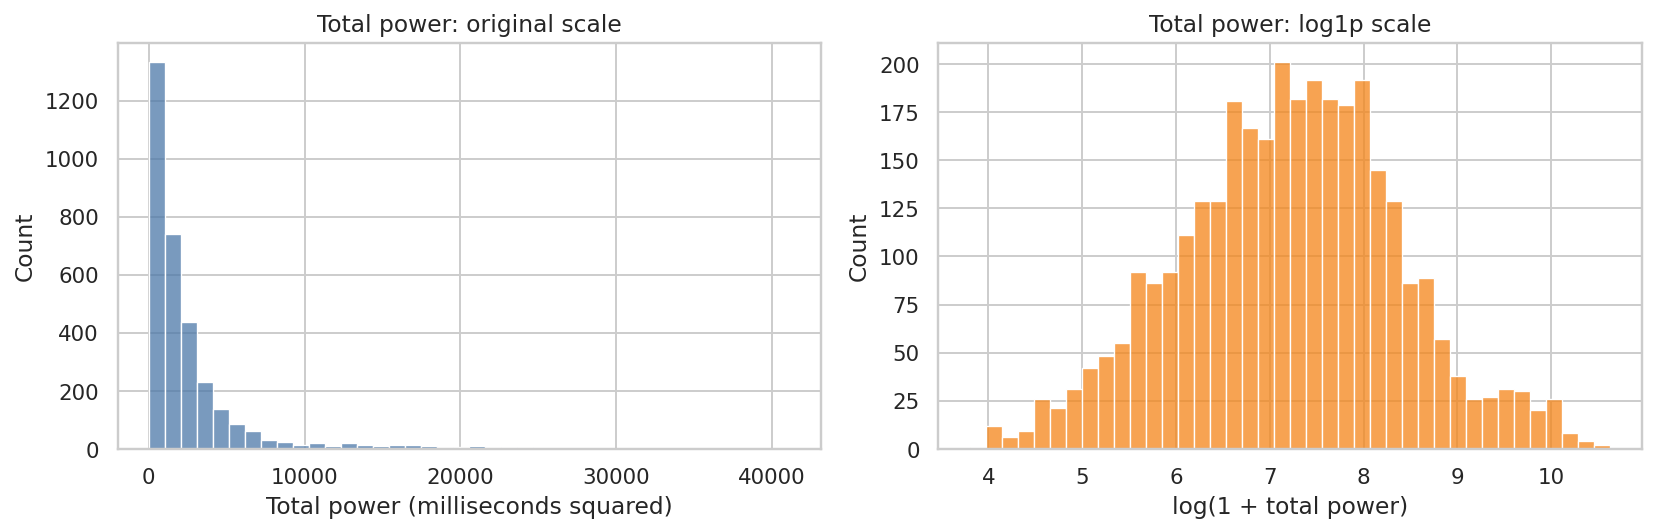

In [13]:
# Create a two-panel comparison using total power as a representative spectral measure.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the original right-skewed distribution.
sns.histplot(
    data=analysis_data,
    x="total_power",
    bins=40,
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Total power: original scale")
axes[0].set_xlabel("Total power (milliseconds squared)")

# Plot the transformed distribution on a compressed scale.
sns.histplot(
    data=analysis_data,
    x="log1p_total_power",
    bins=40,
    color="#F58518",
    ax=axes[1],
)
axes[1].set_title("Total power: log1p scale")
axes[1].set_xlabel("log(1 + total power)")

# Keep panel spacing readable.
plt.tight_layout()

# Render both distributions.
plt.show()


### Outlier interpretation

The IQR rule flags 968 rows (29.83%) on at least one screened measure. This relatively high share is driven by the long right tails of spectral HRV measures rather than negative or impossible values. For example, the raw skewness of `total_power` is 3.79, while its `log1p` skewness is approximately -0.02. The transformation makes the distribution easier to visualize without deleting valid measurements.

I retain raw values for descriptive reporting and use the transformed features only where scale compression improves comparison. This approach separates unusual observations from confirmed data errors.


## 10. Sampling balance

Participants contributed different numbers of HRV measurements. A participant with hundreds of measurements would dominate a measurement-level comparison. I quantify this imbalance and use participant-level medians for demographic comparisons and participant-time-period medians for time-of-day comparisons.


,measurement_count
count,185.00
mean,17.54
std,45.79
min,1.00
25%,1.00
50%,4.00
75%,12.00
90%,40.60
95%,77.60
99%,218.60


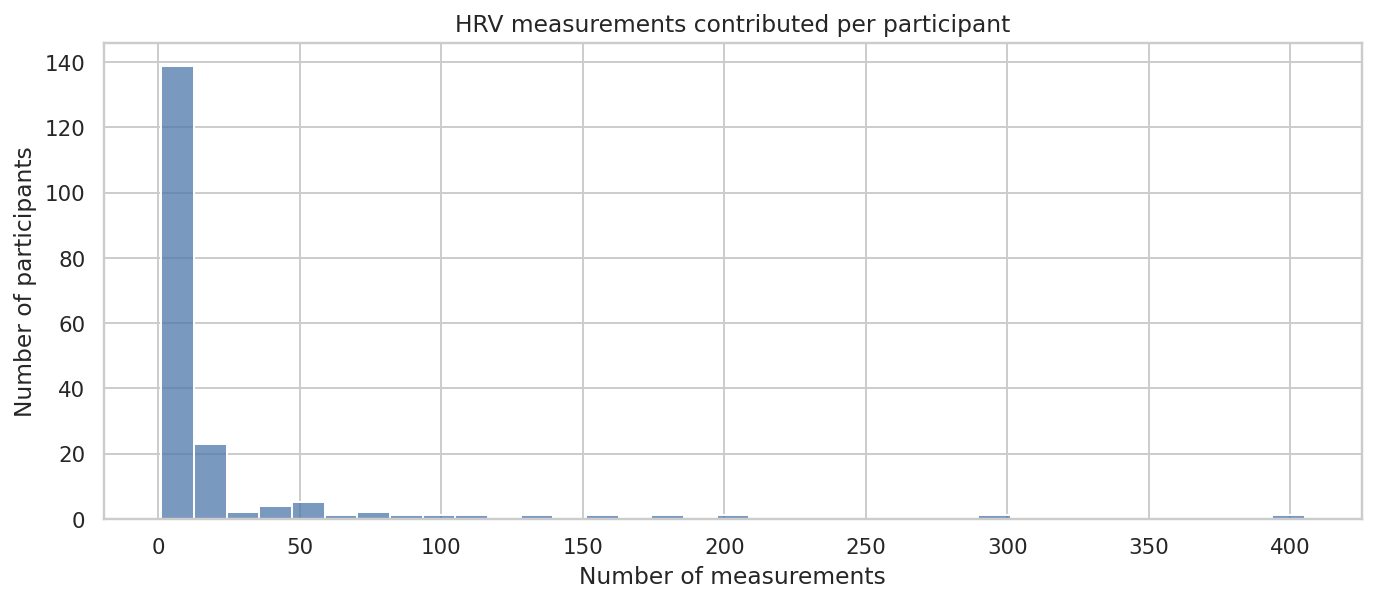

In [14]:
# Count HRV measurements contributed by each participant.
measurements_per_participant = (
    analysis_data.groupby("user_code")
    .size()
    .rename("measurement_count")
)

# Display robust distribution statistics for contribution frequency.
display(
    measurements_per_participant.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).to_frame().round(2)
)

# Create a histogram of participant contribution counts.
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(
    measurements_per_participant,
    bins=35,
    color="#4C78A8",
    ax=ax,
)
ax.set_title("HRV measurements contributed per participant")
ax.set_xlabel("Number of measurements")
ax.set_ylabel("Number of participants")
plt.tight_layout()
plt.show()


The median participant contributed 4 HRV measurements, while the maximum was 405. The mean of 17.54 is much higher than the median because a small number of participants contributed many records. I therefore avoid treating all 3,245 measurements as independent participant observations when comparing demographic or time groups.


## 11. Relationships among HRV variables

Spearman correlation is used because several HRV measures are skewed and contain outliers. It measures monotonic association using ranks and does not require normally distributed variables. The correlations remain descriptive because repeated measurements from the same participant are not independent.


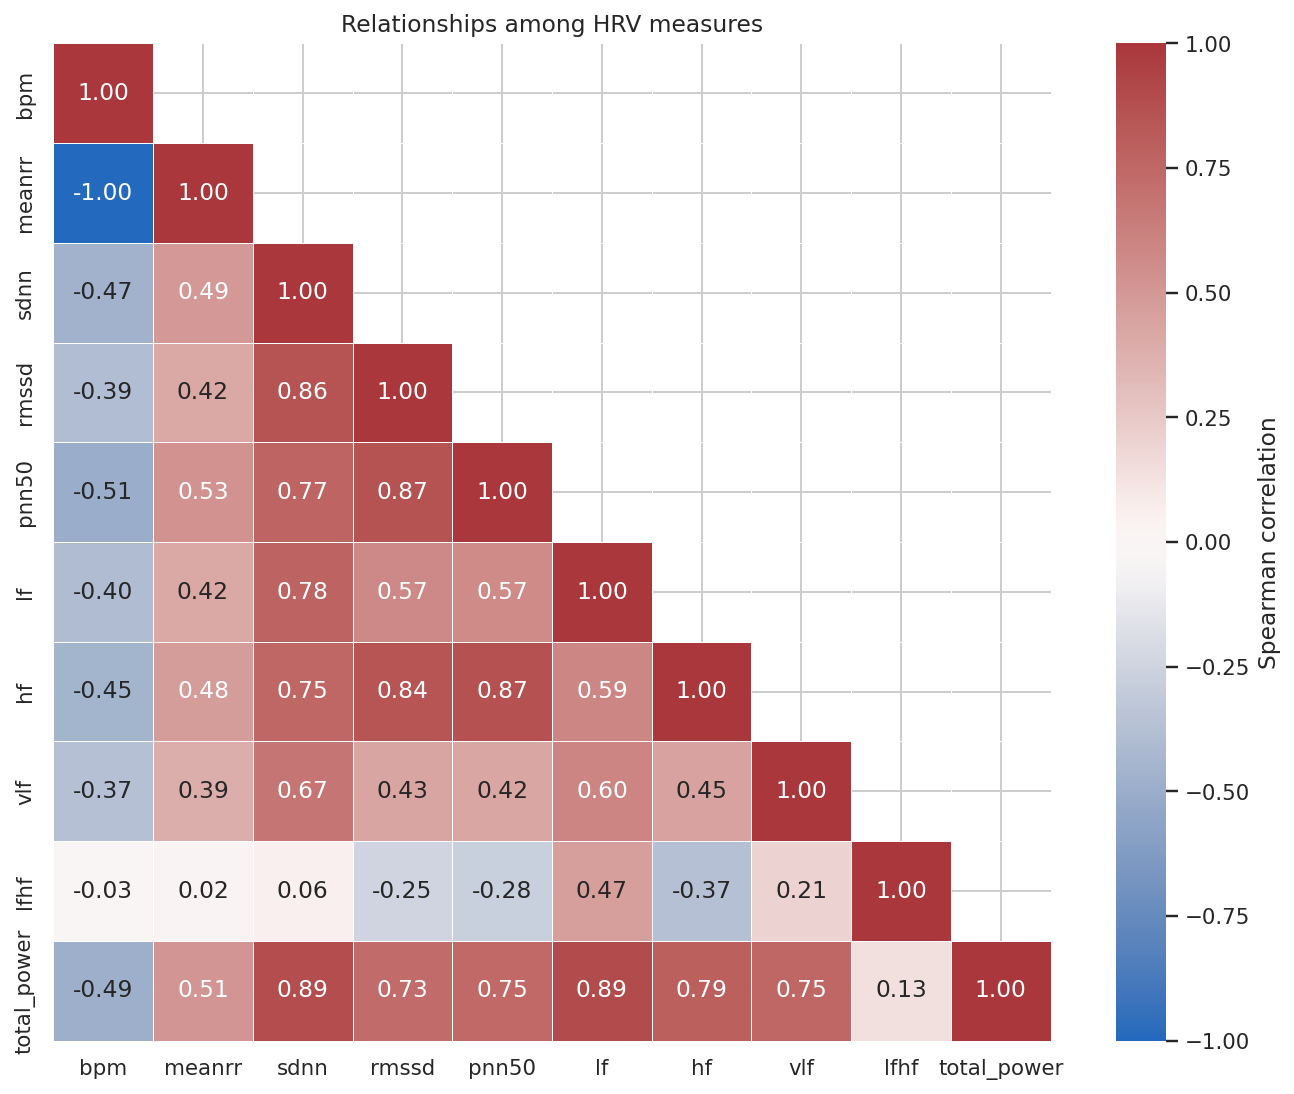

In [15]:
# Select interpretable HRV variables for the relationship matrix.
correlation_columns = [
    "bpm",
    "meanrr",
    "sdnn",
    "rmssd",
    "pnn50",
    "lf",
    "hf",
    "vlf",
    "lfhf",
    "total_power",
]

# Calculate rank-based Spearman correlations.
spearman_correlation = analysis_data[correlation_columns].corr(method="spearman")

# Create a mask so the duplicate upper half of the symmetric matrix is hidden.
upper_triangle_mask = np.triu(
    np.ones_like(spearman_correlation, dtype=bool),
    k=1,
)

# Draw the annotated heatmap.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    spearman_correlation,
    mask=upper_triangle_mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)
ax.set_title("Relationships among HRV measures")
plt.tight_layout()
plt.show()


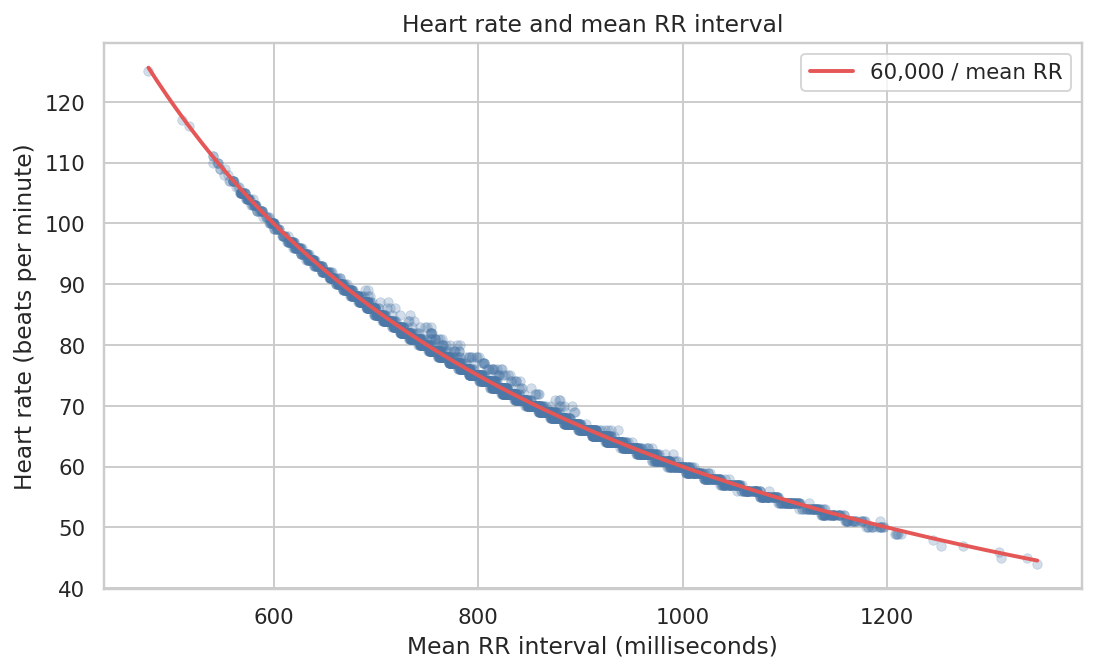

In [16]:
# Plot the mathematical relationship between mean RR interval and heart rate.
fig, ax = plt.subplots(figsize=(8, 5))

# Use partial transparency because many observations overlap.
sns.scatterplot(
    data=analysis_data,
    x="meanrr",
    y="bpm",
    alpha=0.25,
    s=24,
    color="#4C78A8",
    edgecolor=None,
    ax=ax,
)

# Create a smooth sequence of mean-RR values across the observed range.
rr_grid = np.linspace(
    analysis_data["meanrr"].min(),
    analysis_data["meanrr"].max(),
    300,
)

# Overlay the theoretical beats-per-minute conversion.
ax.plot(
    rr_grid,
    60000 / rr_grid,
    color="#E45756",
    linewidth=2,
    label="60,000 / mean RR",
)

ax.set_title("Heart rate and mean RR interval")
ax.set_xlabel("Mean RR interval (milliseconds)")
ax.set_ylabel("Heart rate (beats per minute)")
ax.legend()
plt.tight_layout()
plt.show()


### Relationship interpretation

`bpm` and `meanrr` have an almost perfect negative Spearman correlation (-0.999), which matches their inverse mathematical relationship. `sdnn` and `total_power` are strongly positively associated (0.890), as are `rmssd` and `pnn50` (0.867). These relationships are consistent with the variables describing related aspects of heart-rate variability.

Correlation does not imply that one measure causes another, and the coefficients should not be treated as independent-sample estimates because participants appear repeatedly.


## 12. HRV by time of day

To limit over-weighting of frequent contributors, I first calculate each participant's median HRV within each available time-of-day category. The chart compares those participant-level summaries rather than every raw measurement.


,participant_summaries,source_measurements,median_bpm,median_sdnn,median_rmssd
time_of_day,,,,,
morning,129,1467,71.0,53.02,49.64
day,123,806,77.0,46.61,42.55
evening,113,701,74.0,44.93,43.12
night,39,271,75.0,42.42,41.39


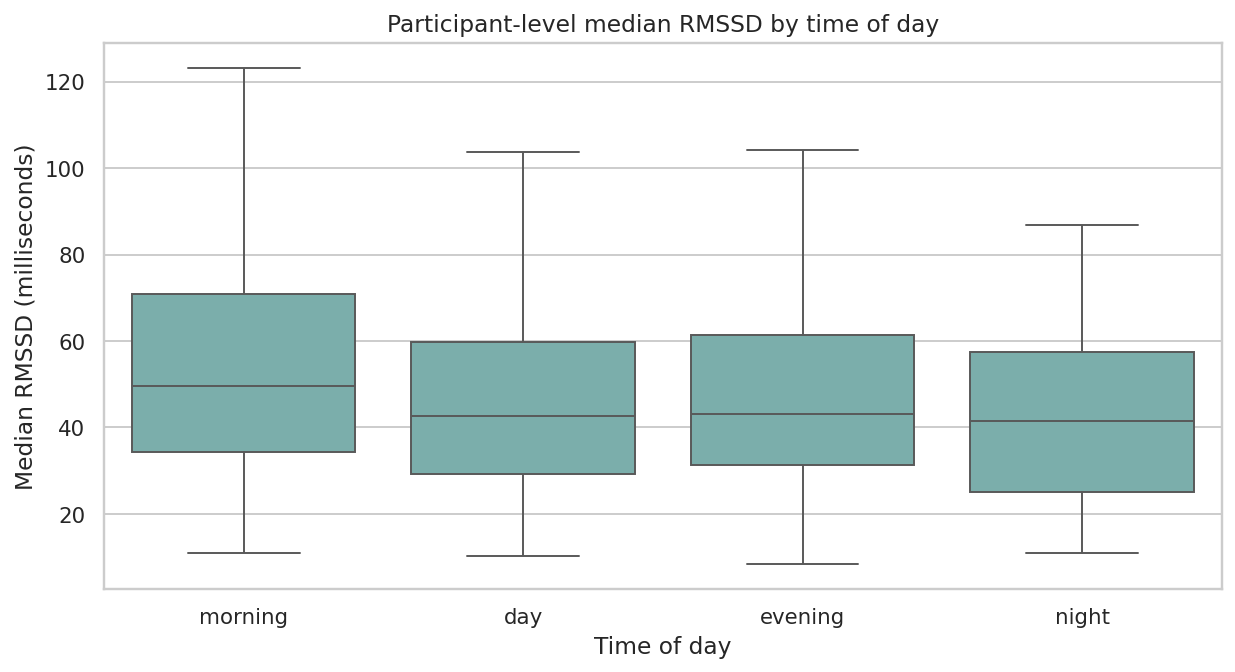

In [17]:
# Define an intuitive order for the four documented time categories.
time_order = ["morning", "day", "evening", "night"]

# Aggregate repeated measurements to one median per participant and time category.
participant_time_summary = (
    analysis_data.groupby(
        ["user_code", "time_of_day"],
        as_index=False,
        observed=True,
    )
    .agg(
        measurement_count=("rr_code", "size"),
        median_bpm=("bpm", "median"),
        median_sdnn=("sdnn", "median"),
        median_rmssd=("rmssd", "median"),
    )
)

# Summarize participant coverage and central values for each time category.
time_of_day_table = (
    participant_time_summary.groupby("time_of_day", observed=True)
    .agg(
        participant_summaries=("user_code", "size"),
        source_measurements=("measurement_count", "sum"),
        median_bpm=("median_bpm", "median"),
        median_sdnn=("median_sdnn", "median"),
        median_rmssd=("median_rmssd", "median"),
    )
    .reindex(time_order)
)

display(time_of_day_table.round(2))

# Plot participant-level RMSSD distributions across time categories.
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=participant_time_summary,
    x="time_of_day",
    y="median_rmssd",
    order=time_order,
    color="#72B7B2",
    showfliers=False,
    ax=ax,
)
ax.set_title("Participant-level median RMSSD by time of day")
ax.set_xlabel("Time of day")
ax.set_ylabel("Median RMSSD (milliseconds)")
plt.tight_layout()
plt.show()


Morning has the lowest median heart rate (71 bpm) and the highest participant-level median SDNN (53.02 ms) and RMSSD (49.64 ms). Night has only 39 participant summaries, compared with 113-129 in the other categories, so its distribution is less stable. These are descriptive differences and may reflect participant routines, measurement conditions, or who measured at each time rather than a pure time-of-day effect.


## 13. HRV relative to reported symptom onset

This exploratory view uses only participants with a valid 2020 symptom-onset date. To reduce the influence of participants with many measurements, I first calculate a median for each participant within each symptom period. The period labels are descriptive and do not represent verified clinical stages.


,participants,source_measurements,median_bpm,median_sdnn,median_rmssd,median_pnn50
symptom_period,,,,,,
Before onset,19,714,73.0,46.96,42.38,17.17
Days 0-7,44,148,75.0,47.16,44.22,15.15
Days 8-14,56,267,73.5,49.64,49.85,17.68
Days 15-30,63,574,75.0,46.99,45.42,13.13
After day 30,62,982,74.0,46.54,43.93,15.15


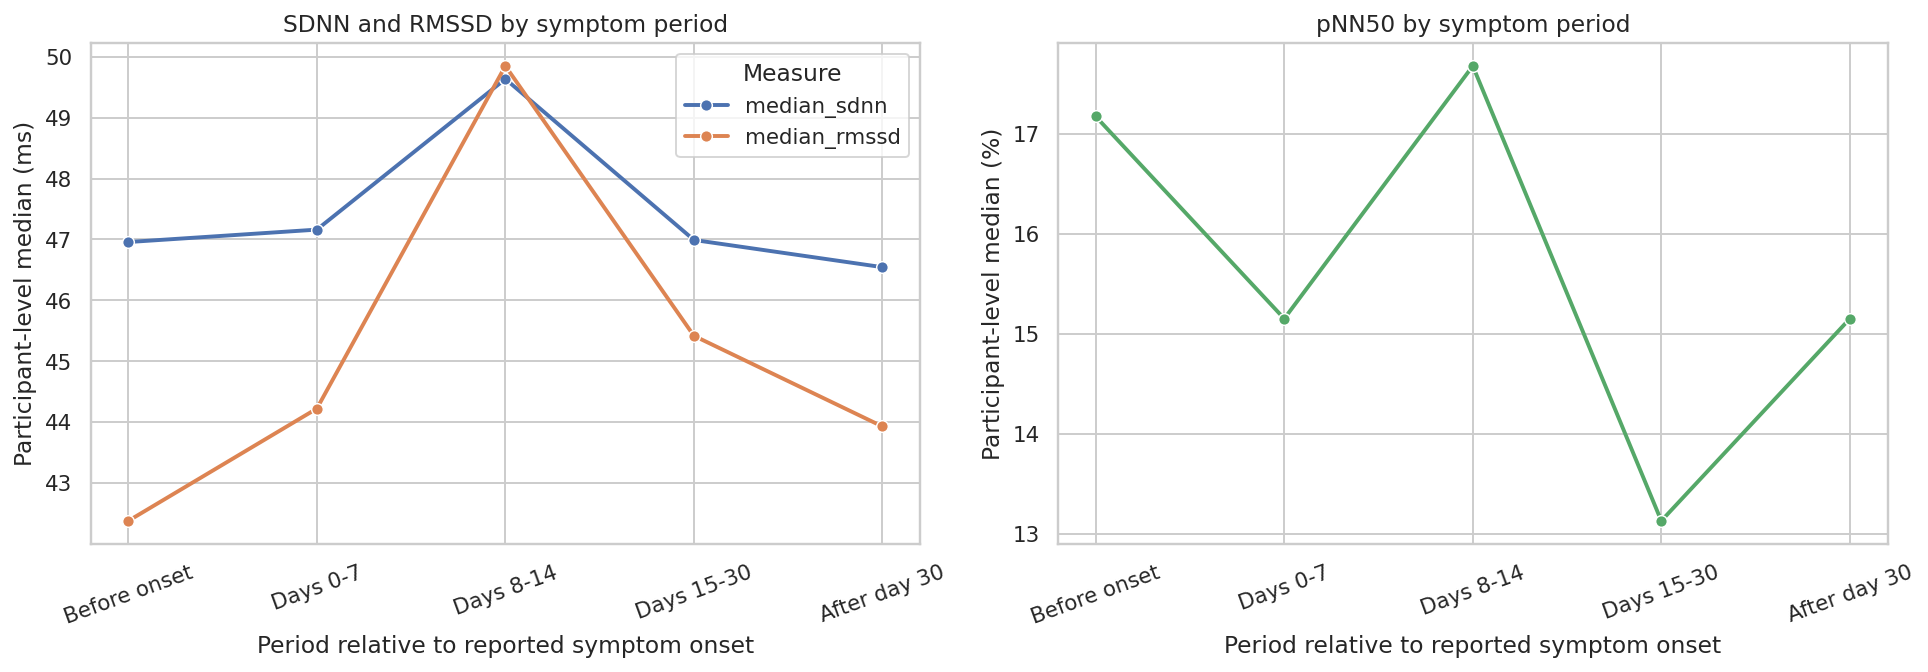

In [18]:
# Keep only rows that have a valid symptom-period assignment.
timeline_data = analysis_data.dropna(subset=["symptom_period"]).copy()

# Aggregate to one record per participant and symptom period.
participant_period_summary = (
    timeline_data.groupby(
        ["user_code", "symptom_period"],
        as_index=False,
        observed=True,
    )
    .agg(
        measurement_count=("rr_code", "size"),
        median_bpm=("bpm", "median"),
        median_sdnn=("sdnn", "median"),
        median_rmssd=("rmssd", "median"),
        median_pnn50=("pnn50", "median"),
    )
)

# Preserve the order used when the symptom-period feature was created.
period_order = list(analysis_data["symptom_period"].cat.categories)

# Summarize coverage and median values within each symptom period.
symptom_period_table = (
    participant_period_summary.groupby("symptom_period", observed=True)
    .agg(
        participants=("user_code", "nunique"),
        source_measurements=("measurement_count", "sum"),
        median_bpm=("median_bpm", "median"),
        median_sdnn=("median_sdnn", "median"),
        median_rmssd=("median_rmssd", "median"),
        median_pnn50=("median_pnn50", "median"),
    )
    .reindex(period_order)
)

display(symptom_period_table.round(2))

# Reshape SDNN and RMSSD together because both are measured in milliseconds.
timeline_ms_plot_data = (
    symptom_period_table[["median_sdnn", "median_rmssd"]]
    .reset_index()
    .melt(
        id_vars="symptom_period",
        var_name="measure",
        value_name="participant_median",
    )
)

# Use a separate panel for pNN50 because it is a percentage, not milliseconds.
timeline_percent_plot_data = symptom_period_table.reset_index()

# Draw the related measures in two panels without mixing units on one axis.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=timeline_ms_plot_data,
    x="symptom_period",
    y="participant_median",
    hue="measure",
    marker="o",
    linewidth=2,
    ax=axes[0],
)
axes[0].set_title("SDNN and RMSSD by symptom period")
axes[0].set_xlabel("Period relative to reported symptom onset")
axes[0].set_ylabel("Participant-level median (ms)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Measure")

sns.lineplot(
    data=timeline_percent_plot_data,
    x="symptom_period",
    y="median_pnn50",
    marker="o",
    linewidth=2,
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title("pNN50 by symptom period")
axes[1].set_xlabel("Period relative to reported symptom onset")
axes[1].set_ylabel("Participant-level median (%)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### Symptom-timeline interpretation

The number of represented participants varies from 19 before onset to 63 in days 15-30. Participant-level median RMSSD is 42.38 ms before onset, 44.22 in days 0-7, 49.85 in days 8-14, 45.42 in days 15-30, and 43.93 after day 30. Median SDNN and pNN50 also vary modestly across periods.

These patterns are not evidence of recovery or disease effects. The groups contain different participants, timing is self-reported, 51 participants lack a usable onset date after missing and invalid values are considered, and no adjustment is made for age, medication, activity, device, or measurement conditions.


## 14. Participant-level demographic context and BMI feature

Demographic comparisons use one median HRV value per participant so each person receives equal weight. BMI is included as an engineered contextual feature, not as a diagnosis or health classification.


,participants,median_bpm,median_sdnn,median_rmssd,median_bmi
age_range,,,,,
18-24,16,76.0,57.55,60.40,23.67
25-34,46,75.0,50.36,50.64,25.82
35-44,56,74.0,48.21,43.33,23.94
45-54,51,72.5,44.62,42.71,28.13
55-64,9,75.0,46.38,50.47,30.03
65-74,7,78.0,55.06,62.93,36.36


,bmi,median_bpm,median_sdnn,median_rmssd
bmi,1.000,0.188,-0.295,-0.214
median_bpm,0.188,1.000,-0.502,-0.410
median_sdnn,-0.295,-0.502,1.000,0.891
median_rmssd,-0.214,-0.410,0.891,1.000


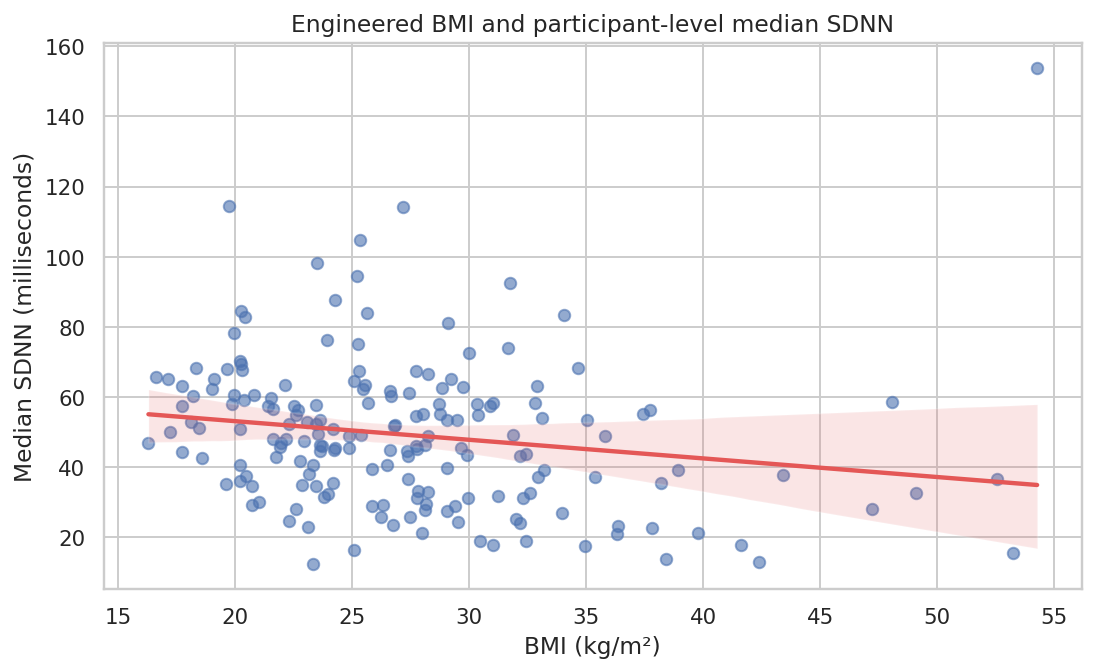

In [19]:
# Aggregate repeated HRV measurements to one summary row per participant.
participant_level = (
    analysis_data.groupby("user_code", as_index=False)
    .agg(
        measurement_count=("rr_code", "size"),
        median_bpm=("bpm", "median"),
        median_sdnn=("sdnn", "median"),
        median_rmssd=("rmssd", "median"),
        gender=("gender", "first"),
        age_range=("age_range", "first"),
        bmi=("bmi", "first"),
    )
)

# Define the natural order of the supplied age bands.
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74"]

# Summarize participant counts and median measures by age range.
age_summary = (
    participant_level.groupby("age_range", observed=True)
    .agg(
        participants=("user_code", "size"),
        median_bpm=("median_bpm", "median"),
        median_sdnn=("median_sdnn", "median"),
        median_rmssd=("median_rmssd", "median"),
        median_bmi=("bmi", "median"),
    )
    .reindex(age_order)
)

display(age_summary.round(2))

# Calculate rank correlations involving the engineered BMI feature.
bmi_relationships = participant_level[
    ["bmi", "median_bpm", "median_sdnn", "median_rmssd"]
].corr(method="spearman")

display(bmi_relationships.round(3))

# Plot BMI against participant-level median SDNN.
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=participant_level,
    x="bmi",
    y="median_sdnn",
    scatter_kws={"alpha": 0.60, "s": 35},
    line_kws={"color": "#E45756"},
    ax=ax,
)
ax.set_title("Engineered BMI and participant-level median SDNN")
ax.set_xlabel("BMI (kg/m²)")
ax.set_ylabel("Median SDNN (milliseconds)")
plt.tight_layout()
plt.show()


BMI has a modest negative Spearman association with participant-level median SDNN (-0.295) and RMSSD (-0.214), and a modest positive association with median heart rate (0.188). These associations are descriptive and may be confounded by age, sex, illness, activity, and uneven measurement conditions. The two height values above 220 cm and two missing heights are excluded from BMI rather than corrected or imputed.


## 15. Data quality assessment

### Data profiling

The analysis profiles all nine tables and 88 features, then examines HRV and participant data in detail. The tables range from 148 to 523,783 rows and use different observation units and time grains.

### Data completeness

Completeness varies sharply by source. Sleep, wearables, and blood-pressure tables have the most missing cells. Within HRV, missingness is limited to optional `how_sleep` and `tags` fields. I retain meaningful missing values and use availability indicators or complete cases for specific calculations rather than applying blanket imputation.

### Data accuracy

All HRV timestamps parse, all core HRV measures are nonnegative, and reported heart rate is closely aligned with mean RR. Thirteen symptom-onset years conflict with the stated 2020 study period, and two heights exceed the conservative BMI rule. These values remain in raw columns but are excluded from affected derived features.

### Data consistency

The identity `total_power = lf + hf + vlf` holds for every HRV record. The documented units are internally coherent, and the categorical HRV scores use the expected five values from -2 through 2. Tables differ in coverage because they originate from different devices and user actions; missing cells should not be interpreted as zeros.

### Data integrity

`rr_code` uniquely identifies all 3,245 HRV measurements, `user_code` uniquely identifies all 185 participants, and every HRV user matches exactly one participant record. There are no exact duplicate rows or repeated user-timestamp pairs in the focus data.

### Data lineage and provenance

Welltory collected the data through its app, Bluetooth heart-rate monitors or smartphone photoplethysmography, connected wearable platforms, and participant assessments. This notebook uses the CSV files from the public Welltory GitHub repository and preserves those raw files unchanged. The precise device, preprocessing history, and measurement conditions are not available for every record, which limits reproducibility at the sensor level.


## 16. Conclusion

The Welltory release is a useful example of real-world multimodal health data. Its strongest qualities are unique identifiers, complete core HRV measures, valid HRV timestamps, and strong internal consistency among related measurements. Its main challenges are uneven table coverage, optional contextual fields, highly unequal measurements per participant, skewed physiological distributions, questionable symptom-onset years, and limited record-level device provenance.

The cleaning process preserves raw observations, removes duplicates only by documented keys, retains meaningful missingness, excludes questionable values only from affected derived features, and handles long-tailed measurements with flags, medians, and log transformations. New features include BMI, measurement hour, sleep/tag availability, days relative to symptom onset, and symptom period.

The descriptive results suggest clear relationships among related HRV measures and differences across time-of-day and symptom-period groups. However, the self-selected sample, repeated observations, uneven contribution rates, self-reported onset dates, and unmeasured confounders prevent causal or clinical conclusions. A follow-up analysis should use a longitudinal repeated-measures design, participant fixed or random effects, device information, and a prespecified clinical protocol.
